# BosonSR Level Transition: Basic Analysis

This notebook runs a compact smoke-analysis of the non-CBC `BosonSR_level` waveform. The GW wrapper loads the isolated level-transition implementation from `../chris/julia_wf/level_transition.jl`.

In [1]:
using Pkg

candidate_dirs = unique([
    abspath(@__DIR__),
    abspath(pwd()),
    joinpath(abspath(@__DIR__), "GW_free_params.jl"),
    joinpath(abspath(pwd()), "GW_free_params.jl"),
])

project_dir_idx = findfirst(dir -> isfile(joinpath(dir, "Project.toml")) && isfile(joinpath(dir, "src", "GW.jl")), candidate_dirs)
project_dir_idx === nothing && error("Could not find GW_free_params.jl project directory from pwd=$(pwd()) and @__DIR__=$(@__DIR__)")
project_dir = candidate_dirs[project_dir_idx]
repo_dir = dirname(project_dir)

wrapper_source = joinpath(project_dir, "src", "waveforms", "bosonSR_level_transition.jl")
level_source = joinpath(repo_dir, "chris", "julia_wf", "level_transition.jl")
@assert isfile(wrapper_source) wrapper_source
@assert isfile(level_source) level_source

Pkg.activate(project_dir)
include(joinpath(project_dir, "src", "GW.jl"))
using .GW
using .GW: BosonSR_level, BosonSR_level_num_der, Pol, Strain, SNR, FisherMatrix, CE1Id_coordinates, CE1Id, ETLS, ETLMR, _available_waveforms
using Plots

default(size=(850, 420), linewidth=2, grid=true)

println("GW project: ", project_dir)
println("GW wrapper: ", wrapper_source)
println("level-transition implementation: ", level_source)

  Activating 

GW project: /home/cherrytree/bosonSR_repo_/GW_free_params.jl

project at `~/bosonSR_repo_/GW_free_params.jl`



GW wrapper: /home/cherrytree/bosonSR_repo_/GW_free_params.jl/src/waveforms/bosonSR_level_transition.jl
level-transition implementation: /home/cherrytree/bosonSR_repo_/chris/julia_wf/level_transition.jl


## Waveform and Parameters

`dL` is in Gpc (`1e-6` Gpc = 1 kpc). The current wrapper returns the slowly varying Lorentzian envelope; the physical transition frequency is reported separately as `f_transition`. The analysis band below is therefore derived from the fitted envelope rather than from the carrier.

In [2]:
model = GW.BosonSR_level(n_time=128, n_fft=1024, n_top=60)

M_solar = 1.0e-6
alpha_sr = 0.75
intrinsic = (M_solar, alpha_sr)

dL = 1.0e-6
theta = 1.0
phi = 2.0
iota = 0.4
psi = 0.7
tcoal = 0.2
phiCoal = 0.0

lorentz_params, f_envelope, _, _ = GW.waveform._level_lorentzian_params(model, M_solar, alpha_sr, dL)
A_fit, f0_fit, gamma_fit, C_fit = lorentz_params
f_transition = GW.waveform._level_transition_frequency(model, M_solar, alpha_sr)
fmin = first(f_envelope)
fmax = min(last(f_envelope), f0_fit + 20.0 * gamma_fit)
fmax > fmin || (fmax = last(f_envelope))
f = collect(range(fmin, fmax, length=800))

println("available non-CBC model: ", GW._available_waveforms("BosonSR_level"))
println("parameter names: ", GW.waveform._parameter_names(model))
println("physical transition frequency [Hz]: ", f_transition)
println("envelope peak and width [Hz]: ", (f0_fit, gamma_fit))
println("analysis band [Hz]: ", (first(f), last(f)))
println("Chris function module: ", GW.waveform.ChrisLevelTransition)

available non-CBC model: BosonSR_level(0.999999, 6, 5, nothing, 1.0, 1.0e-6, 512, 4096, 120, false)
parameter names: (:M_solar, :alpha, :dL, :theta, :phi, :iota, :psi, :tcoal, :phiCoal)
physical transition frequency [Hz]: 8.330248193568449e7
envelope peak and width [Hz]: (4.4387342186741816e-8, 5.892223378925786e-7)
analysis band [Hz]: (1.0399198696213244e-7, 1.1828834100038314e-5)
Chris function module: Main.GW.waveform.ChrisLevelTransition


## Source-Frame Polarizations

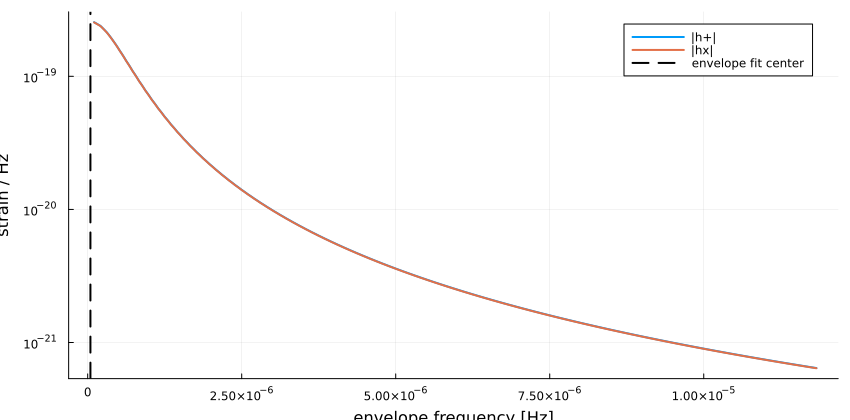

In [3]:
h_plus, h_cross = Pol(model, f, intrinsic, dL, iota)

plot(f, abs.(h_plus), label="|h+|", xlabel="envelope frequency [Hz]", ylabel="strain / Hz", yscale=:log10)
plot!(f, abs.(h_cross), label="|hx|")
vline!([f0_fit], label="envelope fit center", linestyle=:dash, color=:black)

## Detector Strain

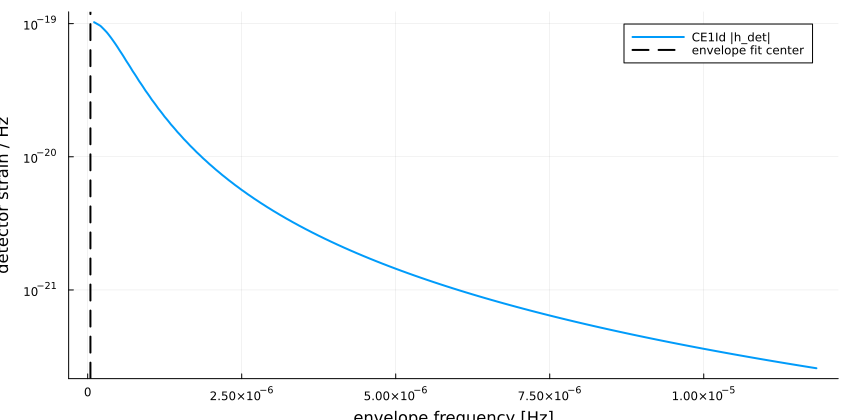

In [4]:
strain_ce = Strain(
    model,
    CE1Id_coordinates,
    f,
    intrinsic,
    dL,
    theta,
    phi,
    iota,
    psi,
    tcoal,
    phiCoal,
)

plot(f, abs.(strain_ce), label="CE1Id |h_det|", xlabel="envelope frequency [Hz]", ylabel="detector strain / Hz", yscale=:log10)
vline!([f0_fit], label="envelope fit center", linestyle=:dash, color=:black)

## SNR

This is a wrapper smoke test. The example envelope lies below the tabulated ground-based detector band, where the detector PSD interpolation uses its configured extrapolation behavior.

In [5]:
network = [ETLS, ETLMR, CE1Id]

M_solar_range = 10.0 .^ range(-6.5, -5.5, length=5)
alpha_range = collect(range(0.65, 0.85, length=5))
snr_matrix = fill(NaN, length(M_solar_range), length(alpha_range));

In [6]:
for (i, M_solar_i) in enumerate(M_solar_range)
    for (j, alpha_j) in enumerate(alpha_range)
        intrinsic_ij = (M_solar_i, alpha_j)
        try
            params_ij, f_env_ij, _, _ = GW.waveform._level_lorentzian_params(model, M_solar_i, alpha_j, dL)
            isempty(f_env_ij) && continue
            _, f0_ij, gamma_ij, _ = params_ij
            fmin_ij = first(f_env_ij)
            fmax_ij = min(last(f_env_ij), f0_ij + 20.0 * gamma_ij)
            fmax_ij > fmin_ij || (fmax_ij = last(f_env_ij))
            fmax_ij > fmin_ij || continue

            snr_matrix[i, j] = SNR(
                model, network, intrinsic_ij, dL, theta, phi, iota, psi, tcoal;
                fmin=fmin_ij, fmax=fmax_ij, res=50,
            )
        catch err
            @warn "SNR calculation failed" M_solar_i alpha_j exception=(err, catch_backtrace())
        end
    end
end

snr_matrix

5×5 Matrix{Float64}:
 8.93556e-27  2.00952e-24  4.0179e-26   5.22314e-26  1.08143e-23
 7.70028e-25  2.15836e-22  3.76912e-24  5.02934e-24  5.05238e-27
 8.63047e-23  6.65938e-26  4.2257e-22   5.41075e-22  3.40385e-25
 3.27599e-26  6.0521e-24   1.36339e-25  1.79521e-25  3.66059e-23
 2.59089e-24  7.2112e-22   1.2162e-23   1.60029e-23  4.13214e-21

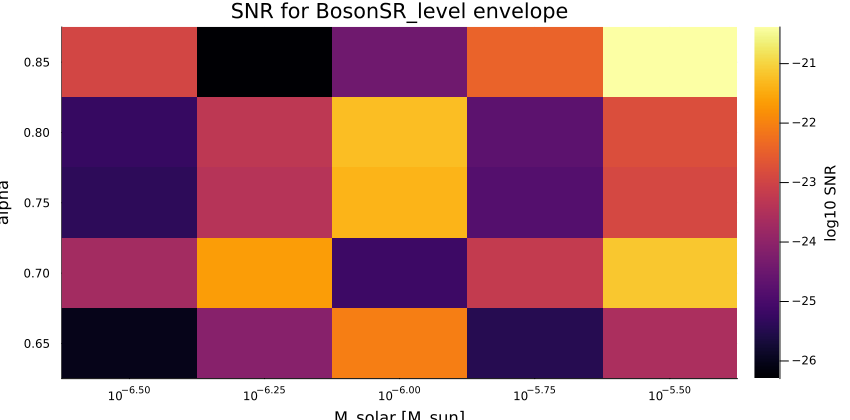

In [7]:
heatmap(
    M_solar_range, alpha_range, log10.(snr_matrix)';
    ylabel="alpha", xlabel="M_solar [M_sun]",
    title="SNR for BosonSR_level envelope", colorbar_title="log10 SNR",
    xscale=:log10,
)

## Small Fisher Matrix

The numerical-derivative level model is used so derivatives of the fitted Lorentzian parameters with respect to `M_solar` and `alpha` are retained. This is intentionally low resolution.

9×9 Matrix{Float64}:
  1.15793e-28  -2.24856e-33   1.41771e-30  …   1.41098e-40  -5.38481e-54
 -2.24856e-33   4.36642e-38  -2.75301e-35     -2.73994e-45   1.0967e-58
  1.41771e-30  -2.75301e-35   1.73576e-32      1.72752e-42   1.09998e-55
 -4.29842e-37   8.347e-42    -5.26275e-39     -2.14411e-48  -2.83388e-44
 -1.94023e-36   3.76769e-41  -2.37551e-38     -3.18475e-48  -1.43505e-44
  5.98274e-37  -1.16177e-41   7.32495e-39  …   7.34158e-49   8.99344e-47
 -2.86048e-39   5.55469e-44  -3.50221e-41      1.98785e-48   3.48274e-44
  1.41098e-40  -2.73994e-45   1.72752e-42      2.2881e-52    9.92463e-49
 -5.38481e-54   1.0967e-58    1.09998e-55      9.92463e-49   1.73576e-44

┌ Warning: No strict ticks found
└ @ PlotUtils /home/cherrytree/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /home/cherrytree/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /home/cherrytree/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /home/cherrytree/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /home/cherrytree/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /home/cherrytree/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /home/cherrytree/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194


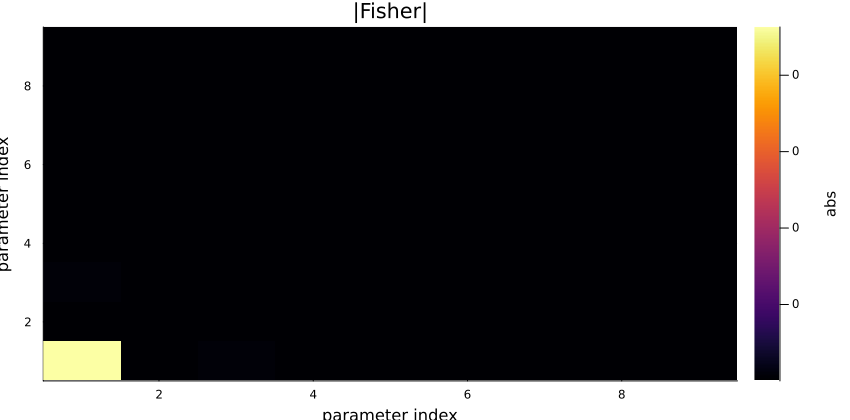

In [8]:
fisher_model = GW.BosonSR_level_num_der(n_time=128, n_fft=1024, n_top=60)
fisher = FisherMatrix(
    fisher_model, CE1Id, intrinsic, dL, theta, phi, iota, psi, tcoal, phiCoal;
    res=40, fmin=fmin, fmax=fmax, rho_thres=nothing,
)

display(fisher)
heatmap(abs.(fisher), xlabel="parameter index", ylabel="parameter index", title="|Fisher|", colorbar_title="abs")

## Median SNR over Extrinsic-Parameter Priors

For each point on the intrinsic grid, this section evaluates the network SNR for 20 common Monte Carlo draws from the catalog priors: `cos(theta), cos(iota) ~ Uniform(-1, 1)`, `phi, phiCoal ~ Uniform(0, 2pi)`, `psi ~ Uniform(0, pi)`, and `tcoal ~ Uniform(0, 1)` day. The plotted value is the median over those draws. `phiCoal` is sampled as part of the full extrinsic tuple but is absent from the SNR API because a constant phase does not change the SNR.

In [9]:
using Random, Statistics

n_extrinsic_samples = 20
prior_rng = MersenneTwister(20260715)
extrinsic_samples = [
    (
        theta=acos(2.0 * rand(prior_rng) - 1.0),
        phi=2.0 * pi * rand(prior_rng),
        iota=acos(2.0 * rand(prior_rng) - 1.0),
        psi=pi * rand(prior_rng),
        tcoal=rand(prior_rng),
        phiCoal=2.0 * pi * rand(prior_rng),
    )
    for _ in 1:n_extrinsic_samples
]

function network_snr_from_polabs(model, network, intrinsic, dL, sample, pol_abs; fmin, fmax, res)
    detector_snrs = [
        SNR(
            model, detector, intrinsic, dL, sample.theta, sample.phi, sample.iota, sample.psi, sample.tcoal;
            fmin=fmin, fmax=fmax, res=res, ampl_precomputation=pol_abs,
        )
        for detector in network
    ]
    return sqrt(sum(abs2, detector_snrs))
end

network_snr_from_polabs (generic function with 1 method)

In [10]:
median_snr_matrix = fill(NaN, length(M_solar_range), length(alpha_range))
prior_res = 50

for (i, M_solar_i) in enumerate(M_solar_range)
    for (j, alpha_j) in enumerate(alpha_range)
        intrinsic_ij = (M_solar_i, alpha_j)
        try
            params_ij, f_env_ij, _, _ = GW.waveform._level_lorentzian_params(model, M_solar_i, alpha_j, dL)
            isempty(f_env_ij) && continue
            _, f0_ij, gamma_ij, _ = params_ij
            fmin_ij = first(f_env_ij)
            fmax_ij = min(last(f_env_ij), f0_ij + 20.0 * gamma_ij)
            fmax_ij > fmin_ij || (fmax_ij = last(f_env_ij))
            fcut_ij = min(GW.waveform._fcut(model, intrinsic_ij...), fmax_ij)
            fcut_ij > fmin_ij || continue
            fgrid_ij = 10.0 .^ range(log10(fmin_ij), log10(fcut_ij), length=prior_res)

            level_amp_ij = GW.waveform._level_spectrum(model, fgrid_ij, M_solar_i, alpha_j, dL)
            sampled_snrs = Float64[]
            for sample in extrinsic_samples
                hp_abs = abs.(0.5 * (1.0 + cos(sample.iota)^2) .* level_amp_ij)
                hc_abs = abs.(cos(sample.iota) .* level_amp_ij)
                pol_abs = [hp_abs, hc_abs]
                push!(sampled_snrs, network_snr_from_polabs(
                    model, network, intrinsic_ij, dL, sample, pol_abs;
                    fmin=fmin_ij, fmax=fmax_ij, res=prior_res,
                ))
            end

            finite_snrs = filter(isfinite, sampled_snrs)
            isempty(finite_snrs) || (median_snr_matrix[i, j] = median(finite_snrs))
        catch err
            @warn "Sampled SNR calculation failed" M_solar_i alpha_j exception=(err, catch_backtrace())
        end
    end
end

median_snr_matrix

5×5 Matrix{Float64}:
 4.4773e-27   1.0069e-24   2.01323e-26  2.61713e-26  5.41868e-24
 3.85834e-25  1.08148e-22  1.88857e-24  2.52003e-24  2.53157e-27
 4.32443e-23  3.33678e-26  2.11735e-22  2.71114e-22  1.70555e-25
 1.64149e-26  3.03249e-24  6.83146e-26  8.99515e-26  1.83419e-23
 1.29821e-24  3.61328e-22  6.09397e-24  8.01847e-24  2.07047e-21

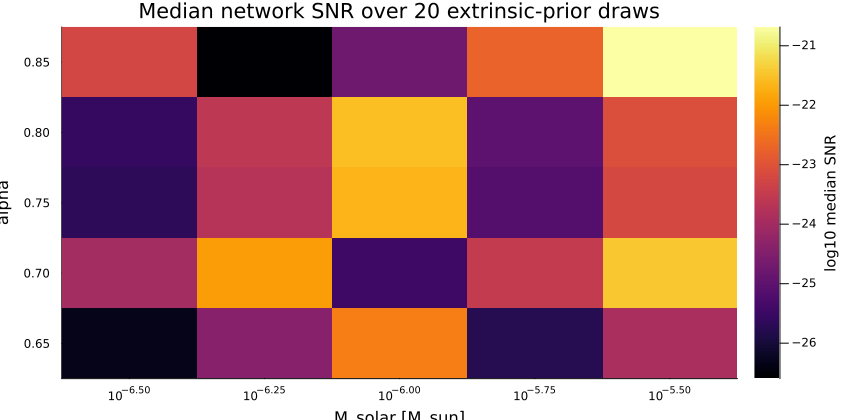

In [11]:
heatmap(
    M_solar_range, alpha_range, log10.(median_snr_matrix)';
    ylabel="alpha", xlabel="M_solar [M_sun]",
    title="Median network SNR over $(n_extrinsic_samples) extrinsic-prior draws",
    colorbar_title="log10 median SNR", xscale=:log10,
)